# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [Jiaxian Wang]

**Date:** [9/4/2026]

In [35]:
# Your Phase 1 solution to the problem goes here. Q1.1
import pandas as pd
df = pd.read_csv("./A01-data-wrangling/data/airbnb_hw.csv")
df.head()
df["Price"].value_counts(dropna=False)
price_numeric = pd.to_numeric(df["Price"], errors="coerce")
problem_rows = df[price_numeric.isna() & df["Price"].notna()]
display(problem_rows.head(20))
df["Price"] = (
    df["Price"]
    .astype("string")
    .str.replace(r'[\$,]', '', regex=True))
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
display(df["Price"].head(20))
missing_price = df["Price"].isna().sum()
print(missing_price)


,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
101,8730,2/27/2009,Comfort & Convenience,Manhattan,Condominium,100.0,Entire home/apt,10003.0,6.0,1,4,"1,990",100.0
263,34915,8/30/2009,Luxurious 2-Floor Manhattan Mansion,Manhattan,Apartment,NaN,Entire home/apt,10075.0,2.0,1,0,"1,000",NaN
764,112879,4/23/2010,Modern Luxury Meets Old Money Charm,Brooklyn,Apartment,NaN,Entire home/apt,11206.0,5.0,1,0,"1,200",NaN
1272,214148,8/26/2010,"LARGE, COMFY 1BDR W/CHARACTER!!!",Brooklyn,Apartment,90.0,Entire home/apt,11216.0,1.0,1,30,"1,000",92.0
1275,213266,8/26/2010,Beautiful 1 Bedroom in Nolita/Soho,Manhattan,Apartment,75.0,Entire home/apt,10012.0,2.0,1,2,"5,000",76.0
1476,256239,10/8/2010,Beautiful 3 bedroom in Manhattan,Manhattan,Apartment,NaN,Private room,10025.0,NaN,1,0,"3,000",NaN
1846,319077,12/14/2010,HUGE loft for film & photoshoots,Brooklyn,Loft,95.0,Entire home/apt,11238.0,4.0,1,6,"1,500",97.0
1973,351384,1/17/2011,"For Walter, King Size Bed",Brooklyn,Other,NaN,Entire home/apt,11211.0,1.0,1,0,"1,200",NaN
1977,351938,1/18/2011,All Star/Fashion weekend/VDAY Pad,Brooklyn,Loft,NaN,Entire home/apt,11231.0,1.0,1,0,"1,800",NaN
2095,391612,2/14/2011,"Victorian House, Express + More!",Brooklyn,House,95.0,Entire home/apt,11226.0,8.0,1,6,"1,300",97.0


,Price
0,145
1,37
2,28
3,199
4,549
5,149
6,250
7,90
8,270
9,290


0


I removed the "$" signs and commas from Price and converted it to numeric. This is important for prices over 999 because those numbers may contain commas. After cleaning, there were 0 missing values.

In [8]:
#Q1.2
import pandas as pd
df_police = pd.read_csv("./A01-data-wrangling/data/mn_police_use_of_force.csv")
missing = df_police["subject_injury"].isna().mean()
print(missing)
pd.crosstab(
    df_police["force_type"],
    df_police["subject_injury"].fillna("Missing"))

0.7619342359767892


subject_injury,Missing,No,Yes
force_type,,,
Baton,2,0,2
Bodily Force,7051,1093,1286
Chemical Irritant,1421,131,41
Firearm,0,2,0
Gun Point Display,27,33,44
Improvised Weapon,74,34,40
Less Lethal,87,0,0
Less Lethal Projectile,0,1,2
Maximal Restraint Technique,170,0,0


There are around 76.19% of the values are missing. It is a concern, because it is a large part of the data. The missing values varies by force types. Some force types,like Less Lethal and Maximal Restraint Technique, have all missing values. Other force types are having fewer missing values.

0.0
2026.0


<Axes: title={'center': 'Shark Attacks Since 1940'}, xlabel='Year', ylabel='Number of Attacks'>

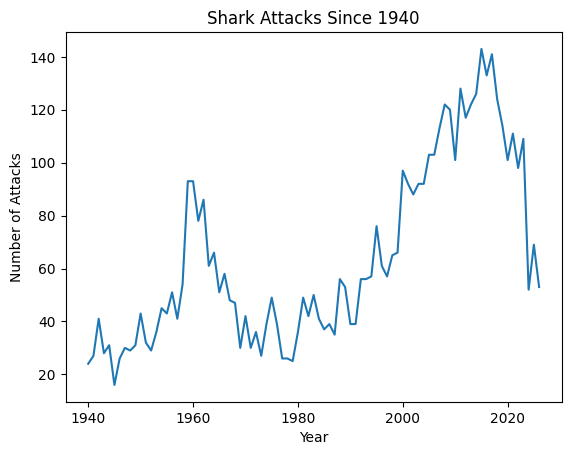

In [23]:
#Q2.1
import pandas as pd
df = pd.read_excel("GSAF5.xls")
#Q2.2
df = df.dropna(how='all', axis=1)
#Q2.3
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
print(df["Year"].min())
print(df["Year"].max())
df_recent = df[df["Year"] >= 1940]
df_recent.groupby("Year").size().plot(
    kind="line",
    title="Shark Attacks Since 1940",
    xlabel="Year",
    ylabel="Number of Attacks")

The year ranges from 0 to 2026. Overall, shark attacks seem to be increasing, but there are lots of ups and downs.

<Axes: title={'center': 'Age of Shark Attack Victims'}, xlabel='Age', ylabel='Frequency'>

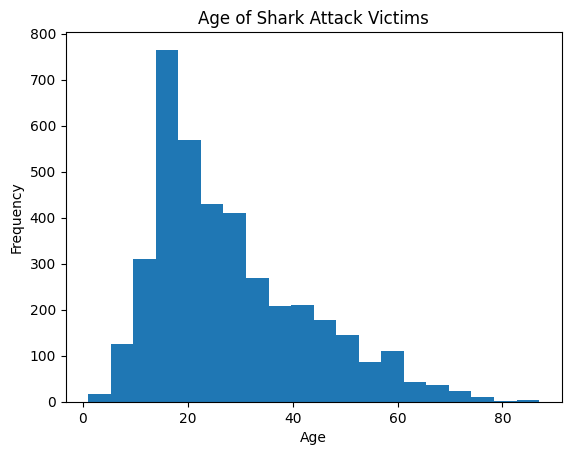

In [24]:
#Q2.4
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Age"].dropna().plot(
    kind="hist",
    bins=20,
    title="Age of Shark Attack Victims",
    xlabel="Age")

In [28]:
#Q2.5
df["Sex"].value_counts()

,count
Sex,
M,5704
F,816
M,7
?,2
N,2
F,2
M F,1
M,1
m,1


In [34]:
s = df["Sex"].astype(str).str.strip().str.upper()
print((s == "M").sum() /s.isin(["M", "F"]).sum())

0.8747511866482928


Around 87.48% of the victims are male.

In [30]:
#Q2.6
df["Type"].value_counts()

,count
Type,
Unprovoked,5261
Provoked,647
Invalid,552
Watercraft,355
Sea Disaster,242
Questionable,27
Boat,7
Provoked,2
unprovoked,1


In [33]:
df["Type"] = df["Type"].astype(str).str.strip().str.capitalize()
df["Type"] = df["Type"].where(
    df["Type"].isin(["Provoked", "Unprovoked"]),"Unknown")
print((df["Type"] == "Unprovoked").mean())

0.7394969790642124


Around 73.95% of the attacks are unprovoked.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** f7fbe89
- **AI tool and model used:** ChatGPT

### *Prompts used

1. Review my Phase 1 solutions for Question 1 and 2. Identify errors, weaknesses and give me specific suggetsions to improve.
2. [Paste follow-up prompt]

### *AI-proposed changes



1.Create a cleaned subject_injury variable.

Instead of only using .fillna("Missing") inside the crosstab, create a separate cleaned column with consistent values such as Yes, No, and Missing.

2.Use missing-value proportions for subject_injury by force_type.

Raw counts can be misleading because different force types have different sample sizes. Calculate the percentage missing within each force type to better identify patterns.

3.Investigate invalid Year values.

After converting Year to numeric, inspect unusual values such as 0. These should likely be treated as missing before reporting the year range or analyzing trends.

4.Inspect nonnumeric Age values before converting them to missing.

Using errors="coerce" may remove useful information from entries such as age ranges or text-based ages. Check these values first and clean recoverable ages when possible.

5.Clarify the denominator for the male proportion.

The current calculation uses only records coded M or F. Clearly state that the result represents the proportion male among records with known M/F values.

6.Inspect Type categories before recoding them.

Instead of automatically changing every value other than Provoked and Unprovoked to Unknown, first examine the original categories and decide how each should be handled.


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1  | Accept  | Creating a new cleaned column would make the data easier to use later. |
| 2  | Accept|Proportions are better because each force_type has a different sample size.|
| 3  |Accept|A year of 0 is not a valid year and should be handled as missing.
4|Accept|Some nonnumeric values may also contain useful information.
5|Accept|I should clearly explain that my calculation only includes M and F values.
6|Accept|I should check the original Type categories before grouping them as Unknown.

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [36]:
# Your Phase 2 solution to the problem goes here.
#Q1.1
import pandas as pd
df = pd.read_csv("./A01-data-wrangling/data/airbnb_hw.csv")
df.head()
df["Price"].value_counts(dropna=False)
price_numeric = pd.to_numeric(df["Price"], errors="coerce")
problem_rows = df[price_numeric.isna() & df["Price"].notna()]
display(problem_rows.head(20))
df["Price"] = (
    df["Price"]
    .astype("string")
    .str.replace(r'[\$,]', '', regex=True))
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
display(df["Price"].head(20))
missing_price = df["Price"].isna().sum()
print(missing_price)

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
101,8730,2/27/2009,Comfort & Convenience,Manhattan,Condominium,100.0,Entire home/apt,10003.0,6.0,1,4,"1,990",100.0
263,34915,8/30/2009,Luxurious 2-Floor Manhattan Mansion,Manhattan,Apartment,NaN,Entire home/apt,10075.0,2.0,1,0,"1,000",NaN
764,112879,4/23/2010,Modern Luxury Meets Old Money Charm,Brooklyn,Apartment,NaN,Entire home/apt,11206.0,5.0,1,0,"1,200",NaN
1272,214148,8/26/2010,"LARGE, COMFY 1BDR W/CHARACTER!!!",Brooklyn,Apartment,90.0,Entire home/apt,11216.0,1.0,1,30,"1,000",92.0
1275,213266,8/26/2010,Beautiful 1 Bedroom in Nolita/Soho,Manhattan,Apartment,75.0,Entire home/apt,10012.0,2.0,1,2,"5,000",76.0
1476,256239,10/8/2010,Beautiful 3 bedroom in Manhattan,Manhattan,Apartment,NaN,Private room,10025.0,NaN,1,0,"3,000",NaN
1846,319077,12/14/2010,HUGE loft for film & photoshoots,Brooklyn,Loft,95.0,Entire home/apt,11238.0,4.0,1,6,"1,500",97.0
1973,351384,1/17/2011,"For Walter, King Size Bed",Brooklyn,Other,NaN,Entire home/apt,11211.0,1.0,1,0,"1,200",NaN
1977,351938,1/18/2011,All Star/Fashion weekend/VDAY Pad,Brooklyn,Loft,NaN,Entire home/apt,11231.0,1.0,1,0,"1,800",NaN
2095,391612,2/14/2011,"Victorian House, Express + More!",Brooklyn,House,95.0,Entire home/apt,11226.0,8.0,1,6,"1,300",97.0


,Price
0,145
1,37
2,28
3,199
4,549
5,149
6,250
7,90
8,270
9,290


0


In [37]:
#Q1.2
import pandas as pd
df_police = pd.read_csv("./A01-data-wrangling/data/mn_police_use_of_force.csv")
df_police["subject_injury_clean"] = df_police["subject_injury"].fillna("Missing")
missing = df_police["subject_injury_clean"].eq("Missing").mean()
print(missing)
pd.crosstab(
    df_police["force_type"],
    df_police["subject_injury_clean"],
    normalize="index")

0.7619342359767892


subject_injury_clean,Missing,No,Yes
force_type,,,
Baton,0.500000,0.000000,0.500000
Bodily Force,0.747720,0.115907,0.136373
Chemical Irritant,0.892028,0.082235,0.025738
Firearm,0.000000,1.000000,0.000000
Gun Point Display,0.259615,0.317308,0.423077
Improvised Weapon,0.500000,0.229730,0.270270
Less Lethal,1.000000,0.000000,0.000000
Less Lethal Projectile,0.000000,0.333333,0.666667
Maximal Restraint Technique,1.000000,0.000000,0.000000


[   0.    5.   77. 1000. 1500. 1518. 1543. 1554. 1555. 1580. 1595. 1617.
 1637. 1638. 1640. 1642. 1691. 1700. 1703. 1721.]
5.0
2026.0


<Axes: title={'center': 'Shark Attacks Since 1940'}, xlabel='Year', ylabel='Number of Attacks'>

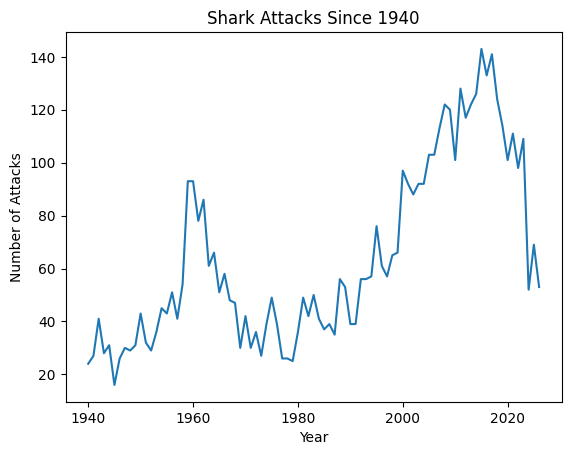

In [38]:
#Q2.1
import pandas as pd
df = pd.read_excel("GSAF5.xls")
#Q2.2
df = df.dropna(how='all', axis=1)
#Q2.3
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
print(df["Year"].sort_values().unique()[:20])
df.loc[df["Year"] <= 0, "Year"] = pd.NA
print(df["Year"].min())
print(df["Year"].max())
df_recent = df[df["Year"] >= 1940]
df_recent.groupby("Year").size().plot(
    kind="line",
    title="Shark Attacks Since 1940",
    xlabel="Year",
    ylabel="Number of Attacks")

Age
?              36
30s            12
Teen           11
20s            10
50s             6
               ..
?    &   14     1
10 or 12        1
31 or 33        1
2½              1
13 or 14        1
Name: count, Length: 90, dtype: int64


<Axes: title={'center': 'Age of Shark Attack Victims'}, xlabel='Age', ylabel='Frequency'>

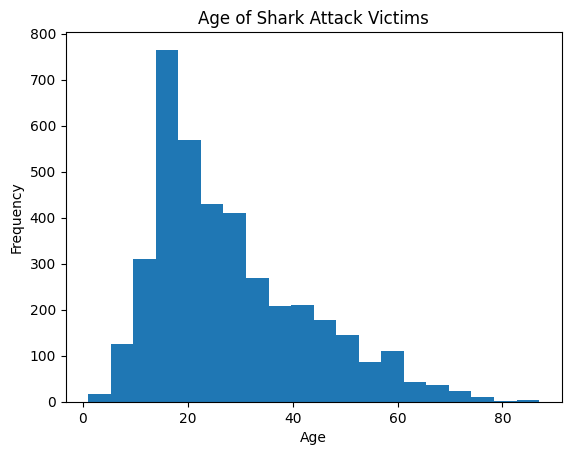

In [39]:
#Q2.4
age_numeric = pd.to_numeric(df["Age"], errors="coerce")
print(df.loc[age_numeric.isna() & df["Age"].notna(), "Age"].value_counts())
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Age"].dropna().plot(
    kind="hist",
    bins=20,
    title="Age of Shark Attack Victims",
    xlabel="Age")

In [40]:
#Q2.5
df["Sex"].value_counts()

,count
Sex,
M,5704
F,816
M,7
?,2
N,2
F,2
M F,1
M,1
m,1


In [41]:
s = df["Sex"].astype(str).str.strip().str.upper()
s1 = s.isin(["M", "F"])
print((s[s1] == "M").mean())

0.8747511866482928


In [42]:
#Q2.6
df["Type"].value_counts(dropna=False)

,count
Type,
Unprovoked,5261
Provoked,647
Invalid,552
Watercraft,355
Sea Disaster,242
Questionable,27
NaN,18
Boat,7
Provoked,2


In [43]:
df["Type"] = df["Type"].astype(str).str.strip().str.capitalize()
df["Type"] = df["Type"].where(
    df["Type"].isin(["Provoked", "Unprovoked"]),"Unknown")
print((df["Type"] == "Unprovoked").mean())

0.7394969790642124


### *Reflection on AI assistance
In your own words without generative AI.

After reviewing my Phase 1 work with AI, I realized some of my original solutions were correct but not careful enough. AI has a much more comprehensive mind than me. I focused more on getting an output, ignored think about how data was cleaned. For example, I did not consider comparing raw missing counts across different force_type groups could be misleading, or converting values directly to numeric could cause useful information missing. These suggestions helped me pay more attention to the decisions behind data cleaning. However, not all AI suggestions should be used. They cannot access the dataset so they are not able to run to check. AI is just an assistance for us to improve our programs, rather than providing standard answers.